In [1]:
import numpy as np
import pymysql
import pandas as pd
# ==================== 1. 범용 경로 설정 ====================
import sys
import os
from typing import Union
from pathlib import Path

def setup_universal_paths():
    """
    어떤 PC에서도 작동하는 범용 경로 설정
    DATA 폴더를 자동으로 찾아 경로 추가
    """
    current = Path.cwd()

    # 상위 폴더를 탐색하며 DATA 폴더 찾기
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            # 프로젝트 루트와 DATA 폴더 모두 추가
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            if str(data_folder) not in sys.path:
                sys.path.insert(0, str(data_folder))

            print("=" * 70)
            print("📁 경로 설정 완료")
            print("=" * 70)
            print(f"✓ 프로젝트 루트: {parent}")
            print(f"✓ DATA 폴더:    {data_folder}")
            print(f"✓ 현재 위치:     {current}")
            print(f"✓ 운영체제:      {os.name}")
            print("=" * 70 + "\n")

            return {
                'project_root': parent,
                'data_folder': data_folder,
                'current': current
            }

    # 못 찾으면 에러
    raise FileNotFoundError(
        f"❌ DATA 폴더를 찾을 수 없습니다.\n"
        f"현재 위치: {current}\n"
        f"상위 폴더에 DATA 폴더가 있는지 확인하세요."
    )

# 경로 설정 실행
try:
    paths = setup_universal_paths()
except FileNotFoundError as e:
    print(e)
    print("\n대안: 수동으로 경로를 설정하세요.")
    # sys.path.insert(0, "여기에_프로젝트_루트_경로_입력")
    sys.exit(1)

📁 경로 설정 완료
✓ 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
✓ DATA 폴더:    C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
✓ 현재 위치:     C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\valuation\kse_valuation_marketcap_forecast
✓ 운영체제:      nt



In [2]:
# -*- coding: utf-8 -*-
"""
시가총액 월말 pivot + 예측 통합 파이프라인
[Step 1] DB 로드 및 월말 기준 pivot 생성
[Step 2] 실제 거래일 -> 표준 월말(MonthEnd) 날짜로 교체
[Step 3] 연속 N개월 이상 데이터 확보된 ticker 필터링
[Step 4] 우선주(끝자리 5) 제거 후 ticker_list 추출
[Step 5] SARIMA / ETS / Theta 예측 -> long format 반환
"""

import pandas as pd
import traceback

from config import get_db_info, get_engine, log, START_DATE_MONTH, END_DATE_MONTH
from universal_ts_forecast_function_v2 import (
    ensure_datetime_index_df,
    forecast_sarima,
    forecast_ets,
    forecast_theta,
    infer_freq_alias,
    seasonal_periods_from_freq,
)

# ============================================================
# 설정
# ============================================================
TABLE_NAME      = 'ks_listed_company_daily_marketcap'
FORECAST_HORIZON: int  = 6     # 예측 기간 (개월). 실행 시 변경 가능
MIN_MONTHS: int        = 60    # 연속 데이터 최소 개월 수
METHODS: list          = ['sarima', 'ets', 'theta']


# ============================================================
# Step 1. DB 로드 및 월말 기준 pivot 생성
# ============================================================
def load_monthly_marketcap_pivot() -> pd.DataFrame:
    db_info = get_db_info()
    engine  = get_engine(db_info)

    query = f"""
        SELECT date, ticker, value
        FROM {TABLE_NAME}
        WHERE indicator = '시가총액'
          AND date >= '{START_DATE_MONTH}'
          AND date <= '{END_DATE_MONTH}'
        ORDER BY date ASC, ticker ASC
    """

    log("LOAD", f"DB 쿼리 시작: {TABLE_NAME}")
    log("LOAD", f"기간: {START_DATE_MONTH} ~ {END_DATE_MONTH}")

    df = pd.read_sql(query, engine)
    log("LOAD", f"원본 데이터 건수: {len(df):,}")

    if df.empty:
        log("WARN", "데이터가 없습니다.")
        return pd.DataFrame()

    df['date']       = pd.to_datetime(df['date'])
    df['year_month'] = df['date'].dt.to_period('M')

    # 연-월별 가장 마지막 거래일을 월말 기준일로 확정
    month_end_dates = (
        df.groupby('year_month')['date']
        .max()
        .reset_index()
        .rename(columns={'date': 'month_end_date'})
    )
    valid_dates = set(month_end_dates['month_end_date'])
    log("LOAD", f"확정된 월말 기준일 수: {len(valid_dates)}개월")

    df_monthly = df[df['date'].isin(valid_dates)].drop(columns=['year_month'])
    log("LOAD", f"월말 필터 후 건수: {len(df_monthly):,}")

    pivot_df = df_monthly.pivot_table(
        index='date',
        columns='ticker',
        values='value',
        aggfunc='first'
    )
    pivot_df.index.name  = 'date'
    pivot_df.columns.name = None
    pivot_df = pivot_df.dropna(axis=1, how='all')

    log("PIVOT", f"shape: {pivot_df.shape}  (월수={pivot_df.shape[0]}, 종목수={pivot_df.shape[1]})")
    return pivot_df


# ============================================================
# Step 2. 실제 거래일 -> 표준 월말(MonthEnd) 날짜로 교체
# ============================================================
def standardize_month_end(pivot_df: pd.DataFrame) -> pd.DataFrame:
    std_dates        = pivot_df.index + pd.offsets.MonthEnd(0)
    pivot_df         = pivot_df.copy()
    pivot_df.index   = std_dates
    pivot_df.index.name = 'date'

    try:
        full_index = pd.date_range(
            start=pivot_df.index.min(),
            end=pivot_df.index.max(),
            freq='ME'   # pandas 2.2+
        )
    except ValueError:
        full_index = pd.date_range(
            start=pivot_df.index.min(),
            end=pivot_df.index.max(),
            freq='M'    # pandas 2.1 이하
        )

    pivot_df            = pivot_df.reindex(full_index)
    pivot_df.index.name = 'date'

    log("STD", f"표준 월말 날짜 교체 완료: {pivot_df.index[0].date()} ~ {pivot_df.index[-1].date()}")
    log("STD", f"표준 월말 index 총 개월 수: {len(full_index)}개월")
    return pivot_df


# ============================================================
# Step 3. 연속 N개월 이상 데이터 확보된 ticker 필터링
# ============================================================
def filter_min_consecutive_months(pivot_df: pd.DataFrame, min_months: int = 60) -> pd.DataFrame:
    def max_consecutive_valid(series: pd.Series) -> int:
        max_len = cur_len = 0
        for val in series:
            if pd.notna(val):
                cur_len += 1
                max_len  = max(max_len, cur_len)
            else:
                cur_len  = 0
        return max_len

    log("FILTER", f"필터링 전 종목 수: {pivot_df.shape[1]:,}")

    consecutive_counts = pivot_df.apply(max_consecutive_valid, axis=0)
    valid_tickers      = consecutive_counts[consecutive_counts >= min_months].index.tolist()
    filtered_df        = pivot_df[valid_tickers].copy()

    log("FILTER", f"연속 {min_months}개월 이상 종목 수: {len(valid_tickers):,}")
    log("FILTER", f"필터링 후 shape: {filtered_df.shape}")
    return filtered_df


# ============================================================
# Step 4. ticker_list 추출 + 우선주(끝자리 5) 제거
# ============================================================
def extract_common_tickers(pivot_df: pd.DataFrame) -> list:
    """
    한국 ticker 형식: 'A' + 6자리 숫자
    우선주 판별: 6자리 숫자의 5번째 자리(index 4)가 '5'
    예) A000020 -> 보통주 유지 / A000025 -> 우선주 제거
    """
    all_tickers = pivot_df.columns.tolist()

    def is_preferred(ticker: str) -> bool:
        code = ticker.lstrip('A')
        return len(code) == 6 and code.isdigit() and code[4] == '5'

    common_tickers = [t for t in all_tickers if not is_preferred(t)]

    log("TICKER", f"전체 ticker: {len(all_tickers)}, 우선주 제거 후: {len(common_tickers)}")
    return common_tickers


# ============================================================
# Step 5. 단일 ticker 예측
# ============================================================
def forecast_one_ticker(
    ticker: str,
    series: pd.Series,
    forecast_horizon: int,
    m: int,
) -> list:
    rows = []

    forecast_funcs = {
        'sarima': lambda: forecast_sarima(
            y=series,
            forecast_horizon=forecast_horizon,
            seasonal_period=m,
            try_transforms=True,
        ),
        'ets': lambda: forecast_ets(
            y=series,
            forecast_horizon=forecast_horizon,
            m=m,
            try_transforms=True,
        ),
        'theta': lambda: forecast_theta(
            y=series,
            forecast_horizon=forecast_horizon,
            m=m,
            try_transforms=True,
        ),
    }

    # 예측 날짜 생성: 마지막 날짜 다음 월말부터 forecast_horizon 개월
    last_date = series.dropna().index[-1]
    try:
        future_dates = pd.date_range(
            start=last_date + pd.offsets.MonthEnd(1),
            periods=forecast_horizon,
            freq='ME'
        )
    except ValueError:
        future_dates = pd.date_range(
            start=last_date + pd.offsets.MonthEnd(1),
            periods=forecast_horizon,
            freq='M'
        )

    for method in METHODS:
        try:
            result = forecast_funcs[method]()

            # 반환 구조: {"forecast": np.array, "spec": {...}} 또는 {"error": "..."}
            if isinstance(result, dict):
                if "error" in result:
                    raise ValueError(result["error"])
                forecast_values = list(result["forecast"])
            elif isinstance(result, pd.Series):
                forecast_values = result.tolist()
            elif hasattr(result, '__iter__'):
                forecast_values = list(result)
            else:
                forecast_values = [result]

            for date, val in zip(future_dates, forecast_values):
                rows.append({
                    'ticker':        ticker,
                    'method':        method,
                    'forecast_date': date,
                    'value':         float(val),
                })

        except Exception:
            log("WARN", f"[{ticker}] {method} 예측 실패 - {traceback.format_exc().splitlines()[-1]}")

    return rows


# ============================================================
# Step 5. 전체 ticker 예측 배치 실행
# ============================================================
def run_forecast_batch(
    pivot_df: pd.DataFrame,
    ticker_list: list,
    forecast_horizon: int = FORECAST_HORIZON,
) -> pd.DataFrame:
    freq_alias = infer_freq_alias(pivot_df.index)
    m          = seasonal_periods_from_freq(freq_alias)
    log("FORECAST", f"freq_alias={freq_alias}, seasonal_period(m)={m}, horizon={forecast_horizon}")

    pivot_df  = ensure_datetime_index_df(pivot_df)
    all_rows  = []
    total     = len(ticker_list)

    for i, ticker in enumerate(ticker_list, 1):
        if ticker not in pivot_df.columns:
            log("WARN", f"[{ticker}] pivot에 없는 ticker - 스킵")
            continue

        series = pivot_df[ticker].dropna()

        if len(series) < 24:
            log("WARN", f"[{ticker}] 데이터 부족({len(series)}개월) - 스킵")
            continue

        log("FORECAST", f"[{i}/{total}] {ticker} 예측 시작 (데이터 {len(series)}개월)")

        rows = forecast_one_ticker(
            ticker=ticker,
            series=series,
            forecast_horizon=forecast_horizon,
            m=m,
        )
        all_rows.extend(rows)

    if not all_rows:
        log("WARN", "예측 결과가 없습니다.")
        return pd.DataFrame(columns=['ticker', 'method', 'forecast_date', 'value'])

    result_df = pd.DataFrame(all_rows)
    result_df['forecast_date'] = pd.to_datetime(result_df['forecast_date'])
    result_df = result_df.sort_values(['ticker', 'method', 'forecast_date']).reset_index(drop=True)

    log("FORECAST", f"예측 완료 - 총 {len(result_df):,}건 (ticker x method x horizon)")
    return result_df


# ============================================================
# 전체 파이프라인
# ============================================================
def build_marketcap_pivot(min_months: int = MIN_MONTHS) -> pd.DataFrame:
    """Step 1~3: pivot 생성 + 날짜 표준화 + 연속 N개월 필터링"""
    pivot_raw = load_monthly_marketcap_pivot()
    if pivot_raw.empty:
        return pd.DataFrame()

    pivot_std      = standardize_month_end(pivot_raw)
    pivot_filtered = filter_min_consecutive_months(pivot_std, min_months=min_months)
    return pivot_filtered


def run_marketcap_forecast(
    forecast_horizon: int = FORECAST_HORIZON,
    min_months: int       = MIN_MONTHS,
    sample_n: int         = None,   # None=전체, 정수=앞에서 N개 ticker만 샘플 예측
    sample_tickers: list  = None,   # 특정 ticker 직접 지정 (예: ['A005930', 'A000660'])
) -> pd.DataFrame:
    """
    Step 1~5 전체 실행: pivot -> 우선주 제거 -> 예측 -> long format 반환

    Args:
        forecast_horizon : 예측 기간 (개월), 기본 6
        min_months       : 연속 데이터 최소 개월 수, 기본 60
        sample_n         : 샘플 테스트용 - ticker_list 앞에서 N개만 실행 (None=전체)
        sample_tickers   : 특정 ticker 직접 지정해서 실행 (None=전체)
    """
    pivot_df = build_marketcap_pivot(min_months=min_months)
    if pivot_df.empty:
        log("WARN", "pivot 데이터가 없습니다.")
        return pd.DataFrame()

    ticker_list = extract_common_tickers(pivot_df)

    # 특정 ticker 직접 지정
    if sample_tickers is not None:
        ticker_list = [t for t in sample_tickers if t in ticker_list]
        log("SAMPLE", f"지정 ticker {len(ticker_list)}개로 실행: {ticker_list}")

    # 앞에서 N개만 샘플
    elif sample_n is not None:
        ticker_list = ticker_list[:sample_n]
        log("SAMPLE", f"샘플 {sample_n}개 ticker로 실행: {ticker_list}")

    else:
        log("SAMPLE", f"전체 {len(ticker_list)}개 ticker 실행")

    result_df = run_forecast_batch(
        pivot_df=pivot_df,
        ticker_list=ticker_list,
        forecast_horizon=forecast_horizon,
    )
    return result_df


# ============================================================
# 실행 진입점
# ============================================================
# if __name__ == '__main__':
#     # -------------------------------------------------------
#     # 실행 모드 선택 (하나만 활성화)
#     # -------------------------------------------------------
#
#     # [모드 1] 전체 예측
#     # result = run_marketcap_forecast(forecast_horizon=6)
#
#     # [모드 2] 앞에서 N개 ticker만 샘플 테스트
#     result = run_marketcap_forecast(forecast_horizon=6, sample_n=5)
#
#     # [모드 3] 특정 ticker 직접 지정
#     # result = run_marketcap_forecast(
#     #     forecast_horizon=6,
#     #     sample_tickers=['A005930', 'A000660', 'A035420']
#     # )
#     # -------------------------------------------------------
#
#     if not result.empty:
#         print(f"\n[예측 결과 요약]")
#         print(f"  총 레코드 수  : {len(result):,}건")
#         print(f"  ticker 수    : {result['ticker'].nunique():,}개")
#         print(f"  예측 방법    : {result['method'].unique().tolist()}")
#         print(f"  예측 날짜 범위: {result['forecast_date'].min().date()} ~ {result['forecast_date'].max().date()}")
#         print(f"\n[미리보기] 상위 20건")
#         print(result.head(20).to_string(index=False))
#
#         # 필요 시 CSV 저장
#         # out_path = 'marketcap_forecast_result.csv'
#         # result.to_csv(out_path, index=False, encoding='utf-8-sig')
#         # log("SAVE", f"저장 완료: {out_path}")

In [3]:
# # [모드 1] 전체 예측
# result = run_marketcap_forecast(forecast_horizon=6)
#
# # [모드 2] 앞에서 N개 ticker만 샘플 테스트
# result = run_marketcap_forecast(forecast_horizon=6, sample_n=5)

# [모드 3] 특정 ticker 직접 지정
result = run_marketcap_forecast(
    forecast_horizon=6,
    sample_tickers=['A005930', 'A000660', 'A035420']
)

[LOAD] DB 쿼리 시작: ks_listed_company_daily_marketcap
[LOAD] 기간: 2011-03-01 ~ 2026-02-28
[LOAD] 원본 데이터 건수: 13,834,435
[LOAD] 확정된 월말 기준일 수: 134개월
[LOAD] 월말 필터 후 건수: 566,039
[PIVOT] shape: (134, 3465)  (월수=134, 종목수=3465)
[STD] 표준 월말 날짜 교체 완료: 2015-01-31 ~ 2026-02-28
[STD] 표준 월말 index 총 개월 수: 134개월
[FILTER] 필터링 전 종목 수: 3,465
[FILTER] 연속 60개월 이상 종목 수: 2,537
[FILTER] 필터링 후 shape: (134, 2537)
[TICKER] 전체 ticker: 2537, 우선주 제거 후: 2289
[SAMPLE] 지정 ticker 3개로 실행: ['A005930', 'A000660', 'A035420']
[FORECAST] freq_alias=M, seasonal_period(m)=12, horizon=6
[FORECAST] [1/3] A005930 예측 시작 (데이터 134개월)
[메모리] forecast_sarima 실행 전: 578.96 MB
[메모리] find_best_sarima_params 실행 전: 578.98 MB
[메모리] find_best_sarima_params 실행 후: 487.49 MB (변화: -91.49 MB)
[메모리] forecast_sarima 실행 후: 478.76 MB (변화: -100.20 MB)
[메모리] forecast_ets 실행 전: 478.76 MB
[메모리] forecast_ets 실행 후: 479.39 MB (변화: +0.63 MB)
[메모리] forecast_theta 실행 전: 479.39 MB
[메모리] forecast_theta 실행 후: 479.56 MB (변화: +0.17 MB)
[FORECAST] [2/3] A000660 예측 시작 (데이터

In [4]:
result

,ticker,method,forecast_date,value
0,A000660,ets,2026-03-31,1.101062e+08
1,A000660,ets,2026-04-30,2.082898e+07
2,A000660,ets,2026-05-31,4.805607e+06
3,A000660,ets,2026-06-30,1.958330e+06
4,A000660,ets,2026-07-31,1.958330e+06
5,A000660,ets,2026-08-31,1.958330e+06
6,A000660,sarima,2026-03-31,1.958330e+06
7,A000660,sarima,2026-04-30,1.958330e+06
8,A000660,sarima,2026-05-31,1.958330e+06
9,A000660,sarima,2026-06-30,1.958330e+06


In [10]:
import pandas as pd


def build_marketcap_visualization_df(
    pivot_df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    ticker_list: list = None,
    methods: list = None,
    history_months: int = None,
    add_bridge: bool = True,
) -> pd.DataFrame:
    """
    실제 시가총액 + 예측 시가총액을 연결하여
    시각화에 바로 사용할 수 있는 long-format 데이터 생성
    """

    if pivot_df is None or pivot_df.empty:
        raise ValueError("pivot_df가 비어 있습니다.")

    if forecast_df is None or forecast_df.empty:
        raise ValueError("forecast_df가 비어 있습니다.")

    # -----------------------------
    # 0. pivot_df 구조 점검
    # -----------------------------
    actual_df = pivot_df.copy()

    # ticker 필터
    if ticker_list is not None:
        keep_cols = [t for t in ticker_list if t in actual_df.columns]
        if not keep_cols:
            raise ValueError(f"pivot_df에 요청한 ticker가 없습니다: {ticker_list}")
        actual_df = actual_df[keep_cols]

    # 최근 N개월
    if history_months is not None and history_months > 0:
        actual_df = actual_df.tail(history_months)

    # index를 date 컬럼으로 강제 변환
    actual_df = actual_df.copy()
    actual_df.index = pd.to_datetime(actual_df.index)
    actual_df.index.name = 'date'

    actual_long = actual_df.stack(dropna=True).reset_index()
    actual_long.columns = ['date', 'ticker', 'value']

    actual_long['data_type'] = 'actual'
    actual_long['method'] = 'actual'
    actual_long['line_group'] = actual_long['ticker'] + '_actual'

    # -----------------------------
    # 2. forecast 정리
    # -----------------------------
    fcst = forecast_df.copy()

    required_cols = {'ticker', 'method', 'forecast_date', 'value'}
    missing_cols = required_cols - set(fcst.columns)
    if missing_cols:
        raise ValueError(f"forecast_df에 필요한 컬럼이 없습니다: {missing_cols}")

    fcst['forecast_date'] = pd.to_datetime(fcst['forecast_date'])

    if ticker_list is not None:
        fcst = fcst[fcst['ticker'].isin(ticker_list)]

    if methods is not None:
        fcst = fcst[fcst['method'].isin(methods)]

    forecast_long = fcst.rename(columns={'forecast_date': 'date'}).copy()
    forecast_long['data_type'] = 'forecast'
    forecast_long['line_group'] = (
        forecast_long['ticker'] + '_' + forecast_long['method']
    )

    forecast_long = forecast_long[
        ['ticker', 'date', 'value', 'data_type', 'method', 'line_group']
    ].copy()

    # -----------------------------
    # 3. bridge row 추가
    # -----------------------------
    bridge_df = pd.DataFrame()

    if add_bridge and not actual_long.empty and not forecast_long.empty:
        actual_last = (
            actual_long
            .sort_values(['ticker', 'date'])
            .groupby('ticker', as_index=False)
            .tail(1)[['ticker', 'date', 'value']]
            .copy()
        )

        forecast_methods = forecast_long[['ticker', 'method']].drop_duplicates()

        bridge_df = actual_last.merge(forecast_methods, on='ticker', how='inner')
        bridge_df['data_type'] = 'bridge'
        bridge_df['line_group'] = bridge_df['ticker'] + '_' + bridge_df['method']
        bridge_df = bridge_df[
            ['ticker', 'date', 'value', 'data_type', 'method', 'line_group']
        ].copy()

    # -----------------------------
    # 4. 최종 결합
    # -----------------------------
    parts = [actual_long, forecast_long]
    if not bridge_df.empty:
        parts.append(bridge_df)

    vis_df = pd.concat(parts, ignore_index=True)
    vis_df = vis_df.sort_values(['ticker', 'line_group', 'date']).reset_index(drop=True)

    return vis_df

In [15]:
# 1. 실제 월말 시가총액 pivot 생성
pivot_df = build_marketcap_pivot(min_months=60)

[LOAD] DB 쿼리 시작: ks_listed_company_daily_marketcap
[LOAD] 기간: 2011-03-01 ~ 2026-02-28
[LOAD] 원본 데이터 건수: 13,834,435
[LOAD] 확정된 월말 기준일 수: 134개월
[LOAD] 월말 필터 후 건수: 566,039
[PIVOT] shape: (134, 3465)  (월수=134, 종목수=3465)
[STD] 표준 월말 날짜 교체 완료: 2015-01-31 ~ 2026-02-28
[STD] 표준 월말 index 총 개월 수: 134개월
[FILTER] 필터링 전 종목 수: 3,465
[FILTER] 연속 60개월 이상 종목 수: 2,537
[FILTER] 필터링 후 shape: (134, 2537)


In [11]:
# 1. 실제 월말 시가총액 pivot 생성
# pivot_df = build_marketcap_pivot(min_months=60)

# 2. 예측 수행
result_df = run_marketcap_forecast(
    forecast_horizon=6,
    min_months=60,
    sample_tickers=['A005930', 'A000660', 'A035420']   # 예시
)

[LOAD] DB 쿼리 시작: ks_listed_company_daily_marketcap
[LOAD] 기간: 2011-03-01 ~ 2026-02-28
[LOAD] 원본 데이터 건수: 13,834,435
[LOAD] 확정된 월말 기준일 수: 134개월
[LOAD] 월말 필터 후 건수: 566,039
[PIVOT] shape: (134, 3465)  (월수=134, 종목수=3465)
[STD] 표준 월말 날짜 교체 완료: 2015-01-31 ~ 2026-02-28
[STD] 표준 월말 index 총 개월 수: 134개월
[FILTER] 필터링 전 종목 수: 3,465
[FILTER] 연속 60개월 이상 종목 수: 2,537
[FILTER] 필터링 후 shape: (134, 2537)
[TICKER] 전체 ticker: 2537, 우선주 제거 후: 2289
[SAMPLE] 지정 ticker 3개로 실행: ['A005930', 'A000660', 'A035420']
[FORECAST] freq_alias=M, seasonal_period(m)=12, horizon=6
[FORECAST] [1/3] A005930 예측 시작 (데이터 134개월)
[메모리] forecast_sarima 실행 전: 512.16 MB
[메모리] find_best_sarima_params 실행 전: 512.16 MB
[메모리] find_best_sarima_params 실행 후: 528.78 MB (변화: +16.62 MB)
[메모리] forecast_sarima 실행 후: 497.83 MB (변화: -14.33 MB)
[메모리] forecast_ets 실행 전: 497.83 MB
[메모리] forecast_ets 실행 후: 498.15 MB (변화: +0.32 MB)
[메모리] forecast_theta 실행 전: 498.15 MB
[메모리] forecast_theta 실행 후: 498.15 MB (변화: +0.00 MB)
[FORECAST] [2/3] A000660 예측 시작 (데이터 

In [16]:

# 3. 시각화용 데이터 생성
vis_df = build_marketcap_visualization_df(
    pivot_df=  pivot_df,
    forecast_df=result_df,
    ticker_list=['A005930', 'A000660', 'A035420'],
    methods=['sarima', 'ets', 'theta'],
    history_months=36,   # 최근 36개월 actual만 사용
    add_bridge=True
)

print(vis_df.head(30).to_string(index=False))

      date  ticker        value data_type method     line_group
2023-03-31 A000660 6.450100e+13    actual actual A000660_actual
2023-04-30 A000660 6.515620e+13    actual actual A000660_actual
2023-05-31 A000660 7.906110e+13    actual actual A000660_actual
2023-06-30 A000660 8.386590e+13    actual actual A000660_actual
2023-07-31 A000660 8.983550e+13    actual actual A000660_actual
2023-08-31 A000660 8.867070e+13    actual actual A000660_actual
2023-09-30 A000660 8.350190e+13    actual actual A000660_actual
2023-10-31 A000660 8.466670e+13    actual actual A000660_actual
2023-11-30 A000660 9.747950e+13    actual actual A000660_actual
2023-12-31 A000660 1.030120e+14    actual actual A000660_actual
2024-01-31 A000660 9.806190e+13    actual actual A000660_actual
2024-02-29 A000660 1.137140e+14    actual actual A000660_actual
2024-03-31 A000660 1.332240e+14    actual actual A000660_actual
2024-04-30 A000660 1.268180e+14    actual actual A000660_actual
2024-05-31 A000660 1.377380e+14    actua

In [17]:
import matplotlib.pyplot as plt


def plot_marketcap_from_vis_df(
    vis_df: pd.DataFrame,
    ticker: str,
    method='sarima',               # 'sarima' / 'ets' / 'theta' / ['sarima','ets']
    title: str = None,
    figsize=(12, 6),
    actual_color='black',
    forecast_color_map=None,
    actual_linewidth=2.5,
    forecast_linewidth=2.0,
    show_bridge=False,
    marker_forecast=True,
    grid=True,
):
    """
    vis_df에서 특정 ticker의 실제값 + 예측값을 시각화

    Parameters
    ----------
    vis_df : pd.DataFrame
        build_marketcap_visualization_df()로 생성된 데이터
        필수 컬럼:
        ['ticker', 'date', 'value', 'data_type', 'method', 'line_group']

    ticker : str
        예: 'A005930'

    method : str or list
        예측 방법 선택
        예: 'sarima'
            ['sarima', 'ets']
            'all'

    title : str, optional
        그래프 제목

    actual_color : str
        실제 데이터 라인 색

    forecast_color_map : dict, optional
        예측 방법별 색 지정
        예:
        {
            'sarima': 'red',
            'ets': 'blue',
            'theta': 'green'
        }

    show_bridge : bool
        bridge 데이터도 점선 연결용으로 같이 그릴지 여부

    marker_forecast : bool
        예측값에 마커 표시 여부
    """

    required_cols = {'ticker', 'date', 'value', 'data_type', 'method', 'line_group'}
    missing_cols = required_cols - set(vis_df.columns)
    if missing_cols:
        raise ValueError(f"vis_df에 필요한 컬럼이 없습니다: {missing_cols}")

    df = vis_df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # ticker 필터
    df = df[df['ticker'] == ticker].copy()
    if df.empty:
        print(f"[WARN] {ticker} 데이터가 없습니다.")
        return

    # method 정리
    if method == 'all':
        selected_methods = sorted(
            df.loc[df['data_type'] == 'forecast', 'method'].dropna().unique().tolist()
        )
    elif isinstance(method, str):
        selected_methods = [method]
    elif isinstance(method, (list, tuple, set)):
        selected_methods = list(method)
    else:
        raise ValueError("method는 str, list, tuple, set 또는 'all' 이어야 합니다.")

    # 기본 색상
    if forecast_color_map is None:
        forecast_color_map = {
            'sarima': 'red',
            'ets': 'blue',
            'theta': 'green'
        }

    plt.figure(figsize=figsize)

    # -------------------------
    # 1. 실제 데이터
    # -------------------------
    actual_df = (
        df[df['data_type'] == 'actual']
        .sort_values('date')
        .copy()
    )

    if not actual_df.empty:
        plt.plot(
            actual_df['date'],
            actual_df['value'],
            color=actual_color,
            linewidth=actual_linewidth,
            label='Actual'
        )

    # -------------------------
    # 2. 예측 데이터
    # -------------------------
    for m in selected_methods:
        # bridge 포함 여부
        if show_bridge:
            fcst_df = df[
                ((df['data_type'] == 'forecast') | (df['data_type'] == 'bridge')) &
                (df['method'] == m)
            ].sort_values('date').copy()
        else:
            fcst_df = df[
                (df['data_type'] == 'forecast') &
                (df['method'] == m)
            ].sort_values('date').copy()

        if fcst_df.empty:
            print(f"[WARN] {ticker} - method={m} 예측 데이터가 없습니다.")
            continue

        plt.plot(
            fcst_df['date'],
            fcst_df['value'],
            linestyle='--',
            linewidth=forecast_linewidth,
            color=forecast_color_map.get(m, None),
            marker='o' if marker_forecast else None,
            label=f'Forecast ({m})'
        )

    # 제목
    if title is None:
        if len(selected_methods) == 1:
            title = f'{ticker} Market Cap: Actual vs Forecast ({selected_methods[0]})'
        else:
            title = f'{ticker} Market Cap: Actual vs Forecast'

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Market Cap')
    plt.legend()
    if grid:
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

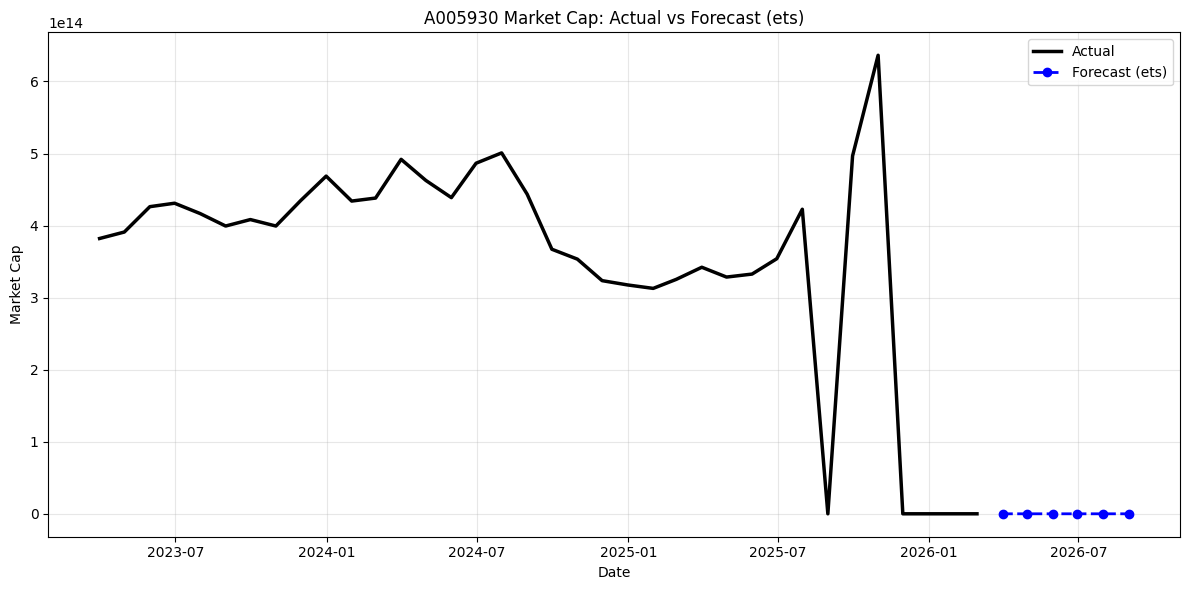

In [19]:
plot_marketcap_from_vis_df(
    vis_df=vis_df,
    ticker='A005930',
    method='ets'
)

In [22]:
pivot_df[['A005930']].tail(20)

,A005930
date,
2024-07-31,5.008650e+14
2024-08-31,4.435550e+14
2024-09-30,3.671420e+14
2024-10-31,3.534110e+14
2024-11-30,3.235620e+14
2024-12-31,3.175920e+14
2025-01-31,3.128170e+14
2025-02-28,3.253530e+14
2025-03-31,3.421550e+14
